# PaES-LLM: Paraconsistent Energy-Saving Large Language Model

**Authors:** Aleyna Ceyran¹ · Prof. Dr. Jair Minoro Abe²

*¹ Sakarya University, Department of Computer Engineering, Turkey*

*² Universidade Paulista (UNIP), Graduate Program in Production Engineering, Brazil*

---

### Introduction
PaES-LLM integrates **Belnap's four-valued logic (L4)** directly into the Transformer architecture as a hardware-aware gating mechanism. An **Epistemic Projector** maps token embeddings into a 2D space: **Evidence (μ)** and **Uncertainty (λ)**. Based on a threshold (τ), tokens are classified into 4 epistemic states:

- **TRUE** (μ ≥ τ, λ < τ): Full compute (Energy coef: 1.0)
- **FALSE** (μ < τ, λ ≥ τ): Hardware bypass / pure noise (Energy coef: 0.0)
- **BOTH** (μ ≥ τ, λ ≥ τ): Contradiction (Energy coef: 0.15)
- **NONE** (μ < τ, λ < τ): Indeterminacy (Energy coef: 0.25)

This notebook serves as a **Quick Start / Proof of Concept** tutorial demonstrating the gating mechanism on a mock **SmolLM-135M** layer.

In [1]:
# Install required packages (uncomment if needed)
# !pip install torch matplotlib

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Setting random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Import PaES components from the repository
import sys
import os
# Repo root: one level up from notebooks/
repo_root = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
# Fallback: current working directory
cwd = os.getcwd()
if cwd not in sys.path:
    sys.path.insert(0, cwd)

from src.models.gated_transformer import GatedTransformerBlock
from src.gating.paes_llm_core import PaESLLMCore

print("✅ Environment setup complete. PaES-LLM modules loaded.")

✅ Environment setup complete. PaES-LLM modules loaded.


In [2]:
# Mock SmolLM-135M Configuration
embed_dim = 256
num_heads = 8
ff_dim = 1024
threshold = 0.5

print(f"Initializing GatedTransformerBlock with τ={threshold}...")

# Instantiate the base SmolLM-135M layer equipped with the GatedTransformerBlock
gated_layer = GatedTransformerBlock(
    embed_dim=embed_dim,
    num_heads=num_heads,
    ff_dim=ff_dim,
    threshold=threshold,
    mode="projector"
)

# To directly visualize the projector's outputs, we also instantiate a standalone PaESLLMCore
projector = PaESLLMCore(embed_dim=embed_dim, threshold=threshold, mode="projector")

print("✅ Model initialization complete.")

Initializing GatedTransformerBlock with τ=0.5...
✅ Model initialization complete.


In [3]:
# Sample Input Text
sample_text = "Quantum computing relies on superposition and decoherence to perform complex calculations."
tokens = sample_text.replace('.', '').split()
seq_len = len(tokens)

print(f"Processing {seq_len} tokens: {tokens}\n")

# Simulate embeddings for the input tokens
# Shape: (batch_size, seq_len, embed_dim)
dummy_embeddings = torch.randn(1, seq_len, embed_dim)

# Pass through the Transformer Block to see the gate in action
out, stats = gated_layer(dummy_embeddings)

print("--- Gated Transformer Layer Stats ---")
print(f"Mean Energy Savings: {stats['mean_savings']*100:.2f}%")
print(f"% Tokens in TRUE:  {stats['attn_pct_true']*100:.1f}%")
print(f"% Tokens in FALSE: {stats['attn_pct_false']*100:.1f}%\n")

# Extract raw evidence (μ) and uncertainty (λ) values for visualization using the standalone core
with torch.no_grad():
    proj = projector.projector(dummy_embeddings)
    mu = torch.sigmoid(proj[..., 0]).squeeze(0)  # Evidence
    lam = torch.sigmoid(proj[..., 1]).squeeze(0) # Uncertainty
    energy_coeff, state_map, proj_stats = projector(dummy_embeddings)
    state_map = state_map.squeeze(0)
    energy_coeff = energy_coeff.squeeze(0)

state_names = {0: 'TRUE', 1: 'FALSE', 2: 'BOTH', 3: 'NONE'}

print(f"{'Token':<15} | {'Evidence (μ)':<12} | {'Uncertainty (λ)':<15} | {'State':<6} | {'Energy Coeff'}")
print("-" * 72)
for i, token in enumerate(tokens):
    print(f"{token:<15} | {mu[i].item():<12.4f} | {lam[i].item():<15.4f} | {state_names[state_map[i].item()]:<6} | {energy_coeff[i].item():.2f}")

Processing 11 tokens: ['Quantum', 'computing', 'relies', 'on', 'superposition', 'and', 'decoherence', 'to', 'perform', 'complex', 'calculations']

--- Gated Transformer Layer Stats ---
Mean Energy Savings: 80.00%
% Tokens in TRUE:  18.2%
% Tokens in FALSE: 36.4%

Token           | Evidence (μ) | Uncertainty (λ) | State  | Energy Coeff
------------------------------------------------------------------------
Quantum         | 0.3863       | 0.1611          | NONE   | 0.25
computing       | 0.4416       | 0.0862          | NONE   | 0.25
relies          | 0.3219       | 0.4898          | NONE   | 0.25
on              | 0.8169       | 0.6762          | BOTH   | 0.15
superposition   | 0.7580       | 0.9477          | BOTH   | 0.15
and             | 0.8371       | 0.4475          | TRUE   | 1.00
decoherence     | 0.3726       | 0.8324          | FALSE  | 0.00
to              | 0.5746       | 0.4293          | TRUE   | 1.00
perform         | 0.8992       | 0.8327          | BOTH   | 0.15
compl

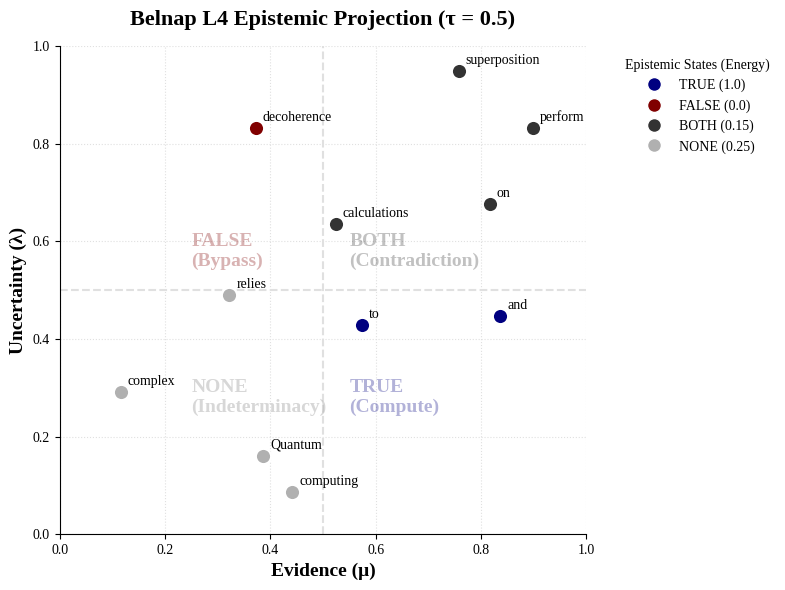

In [4]:
# Set global plot style per project guidelines
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Liberation Serif', 'DejaVu Serif', 'FreeSerif', 'STIXGeneral'],
})

# Project color palette
COLOR_TRUE  = '#000080'  # Navy/Lacivert
COLOR_FALSE = '#800000'  # Maroon/Bordo
COLOR_BOTH  = '#333333'  # Dark Gray
COLOR_NONE  = '#B0B0B0'  # Light Gray
COLOR_GRID  = '#E0E0E0'  # Very Light Gray

state_colors = {
    0: COLOR_TRUE,
    1: COLOR_FALSE,
    2: COLOR_BOTH,
    3: COLOR_NONE
}
state_labels = {0: 'TRUE (1.0)', 1: 'FALSE (0.0)', 2: 'BOTH (0.15)', 3: 'NONE (0.25)'}

fig, ax = plt.subplots(figsize=(8, 6))

# Plot Decision Boundaries (τ)
ax.axhline(threshold, color=COLOR_GRID, linestyle='--', linewidth=1.5, zorder=0)
ax.axvline(threshold, color=COLOR_GRID, linestyle='--', linewidth=1.5, zorder=0)

# Quadrant Labels
ax.text(threshold + 0.05, threshold / 2, 'TRUE\n(Compute)', color=COLOR_TRUE, alpha=0.3, fontsize=14, fontweight='bold')
ax.text(threshold / 2, threshold + 0.05, 'FALSE\n(Bypass)', color=COLOR_FALSE, alpha=0.3, fontsize=14, fontweight='bold')
ax.text(threshold + 0.05, threshold + 0.05, 'BOTH\n(Contradiction)', color=COLOR_BOTH, alpha=0.3, fontsize=14, fontweight='bold')
ax.text(threshold / 2, threshold / 2, 'NONE\n(Indeterminacy)', color=COLOR_NONE, alpha=0.5, fontsize=14, fontweight='bold')

# Scatter plot of tokens
for i in range(len(tokens)):
    st = state_map[i].item()
    ax.scatter(mu[i].item(), lam[i].item(), color=state_colors[st], s=120, edgecolors='white', linewidth=1.5, zorder=3)
    ax.annotate(tokens[i], (mu[i].item(), lam[i].item()), 
                xytext=(5, 5), textcoords='offset points', 
                fontsize=10, fontfamily='serif')

# Customizing limits and labels
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Evidence (μ)', fontsize=14, fontweight='bold')
ax.set_ylabel('Uncertainty (λ)', fontsize=14, fontweight='bold')
ax.set_title(f'Belnap L4 Epistemic Projection (τ = {threshold})', fontsize=16, pad=15, fontweight='bold')

# Styling: Remove top and right spines for academic look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle=':', color=COLOR_GRID, zorder=0)

# Legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=l) 
           for s, c in state_colors.items() for l in [state_labels[s]]]
ax.legend(handles=handles, title='Epistemic States (Energy)', loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False)

plt.tight_layout()
plt.show()